In [1]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
import torch.multiprocessing as mp
from matplotlib import pyplot as plt

# Python 3.14 在 Linux 上默认启动方法从 fork 改为 forkserver;
# forkserver 会在子进程中重新导入 __main__, 而 Jupyter 的 __main__
# 是 ipykernel 启动器, 找不到 notebook 里定义的 worker, 因此报
# AttributeError: module '__main__' has no attribute 'worker'.
# 在 notebook 环境下强制使用 fork 可直接共享父进程内存中的定义.
mp.set_start_method("fork", force=True)

env = gym.make("CartPole-v1")

In [2]:
class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4,25)
        self.l2 = nn.Linear(25,50)
        self.actor_lin1 = nn.Linear(50,2)
        self.l3 = nn.Linear(50,25)
        self.critic_lin1 = nn.Linear(25,1)

    def forward(self,x):
        # we first normalize the input so that the state values are all within the same range
        x = F.normalize(x, dim=0) 
        y = F.relu(self.l1(x))
        y = F.relu(self.l2(y))
        actor = F.log_softmax(self.actor_lin1(y), dim=0)
        y = F.relu(self.l3(y.detach()))
        critic = torch.tanh(self.critic_lin1(y))

        return actor, critic


In [3]:
model = ActorCritic()

# The shared_memory() method will allow the parameters of the model 
# to be shared across processes rather than being copied.
model.share_memory() 

processes = []

params = {
    'epochs': 1000,
    'n_workers': 15,
}
counter = mp.Value('i', 0)
# A shared global counter using multiprocessing’s built-in shared object.
# The ‘i’ parameter indicates the type is integer.

manager = mp.Manager()

history = manager.list()

In [4]:
def run_episode(env:gym.Env, model:nn.Module, N_steps=10):
    state = torch.from_numpy(env.unwrapped.state).float()
    values, logprobs, rewards = [], [], []
    done = False
    j = 0

    G = torch.Tensor([0])

    while done != True and j < N_steps:

        j += 1

        policy, value = model(state)
        values.append(value)
        
        action_dist = torch.distributions.Categorical(logits=policy)
        action = action_dist.sample()
        logprob = policy[action]
        
        logprobs.append(logprob)

        state_, reward, done, _ , _ = env.step(action.detach().numpy())
        state = torch.from_numpy(state_).float()
        
        if done:
            reward = -10
            env.reset()
        else: 
            G = value.detach()

        rewards.append(reward)
    # done 标志本 rollout 结束时是否发生真实终止 (episode 结束)
    return values, logprobs, rewards, G, done


In [5]:
def update_params(optim, values, logprobs, rewards, G, clc=0.1, gamma=0.99):
    rewards = torch.Tensor(rewards).flip(dims=(0,))
    logprobs = torch.stack(logprobs).flip(dims=(0,))
    values = torch.stack(values).flip(dims=(0,))
    Returns = []
    ret = G
    for r in rewards:
        ret = r + gamma * ret
        Returns.append(ret)

    Returns = torch.stack(Returns).view(-1)
    Returns = F.normalize(Returns, dim=0)
    
    # Important to prevent the rl from collapse
    actor_loss = - logprobs * (Returns - values.detach()) 

    critic_loss = torch.pow(Returns - values, 2)
    loss = actor_loss.sum() + critic_loss.sum() * clc
    loss.backward()
    optim.step()
    
    return actor_loss, critic_loss, loss

def worker(rank, shared_model, counter, params, history):
    worker_env = gym.make("CartPole-v1")
    worker_env.reset()
    worker_opt = optim.Adam(lr=1e-3,params=shared_model.parameters())
    worker_opt.zero_grad()

    ep_len_running = 0  # 跨 rollout 累积的真实 episode 长度
    for i in range(params['epochs']):
        worker_opt.zero_grad()

        values, logprobs, rewards, G, ep_done = run_episode(worker_env, shared_model)
        actor_loss, critic_loss, loss, = update_params(worker_opt,values,logprobs,rewards,G)

        ep_len_running += len(rewards)
        # 只在 episode 真正结束时记录 eplen (代表整局撑了多久, 上限 500)
        finished_ep_len = ep_len_running if ep_done else None
        if ep_done:
            ep_len_running = 0

        history.append({
            "step": counter.value,
            "worker": rank,
            "eplen": len(rewards),           # 保留原字段: n-step rollout 长度
            "episode_len": finished_ep_len,  # 新字段: 完整 episode 长度
            "actor_loss": actor_loss.sum().item(),
            "critic_loss": critic_loss.sum().item(),
            "loss": loss.item()
        })
        with counter.get_lock():
            step = counter.value
            counter.value += 1


In [6]:
for i in range(params['n_workers']):
    p = mp.Process(target=worker, args=(i, model, counter, params, history))
    p.start()
    processes.append(p)
for p in processes:
    p.join()
for p in processes:
    p.terminate()

# 4-5 mins

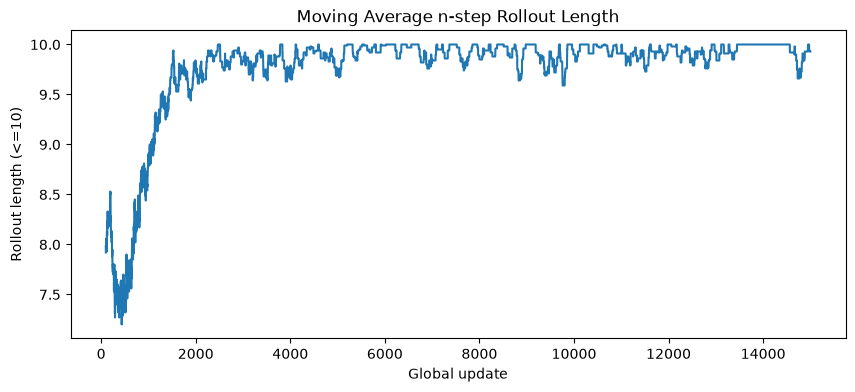

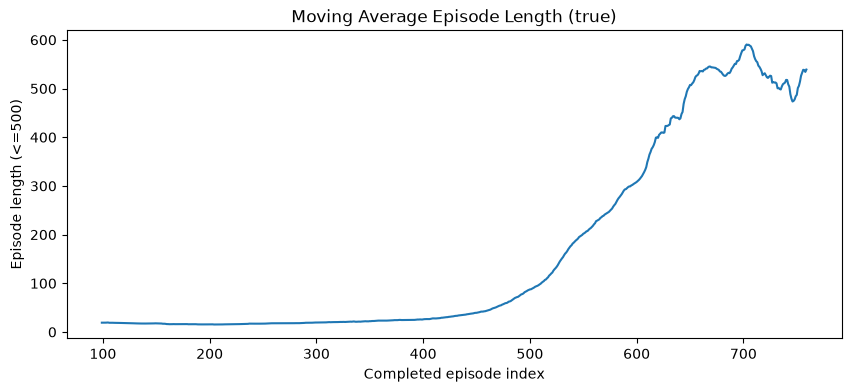

In [7]:
import pandas as pd

df = pd.DataFrame(list(history))
df = df.sort_values("step")

window = 100

# 原图: n-step rollout 长度 (上限 10, 训练用信号)
plt.figure(figsize=(10,4))
plt.plot(df["step"], df["eplen"].rolling(window).mean())
plt.xlabel("Global update")
plt.ylabel("Rollout length (<=10)")
plt.title("Moving Average n-step Rollout Length")
plt.show()

# 新图: 完整 episode 长度 (上限 500, 真正衡量策略好坏)
ep_df = df.dropna(subset=["episode_len"]).reset_index(drop=True)
plt.figure(figsize=(10,4))
plt.plot(ep_df.index, ep_df["episode_len"].rolling(window).mean())
plt.xlabel("Completed episode index")
plt.ylabel("Episode length (<=500)")
plt.title("Moving Average Episode Length (true)")
plt.show()


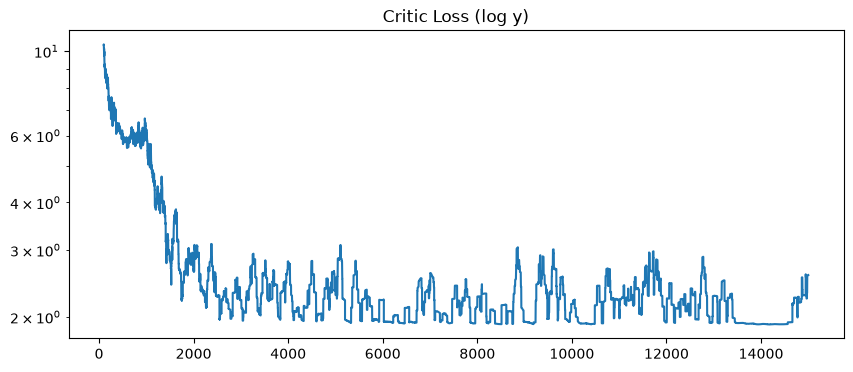

In [8]:
plt.figure(figsize=(10,4))
plt.plot(df["step"], df["critic_loss"].rolling(window).mean())
plt.yscale("log")  # critic_loss = (Returns - values)^2, 恒非负
plt.title("Critic Loss (log y)")
plt.show()

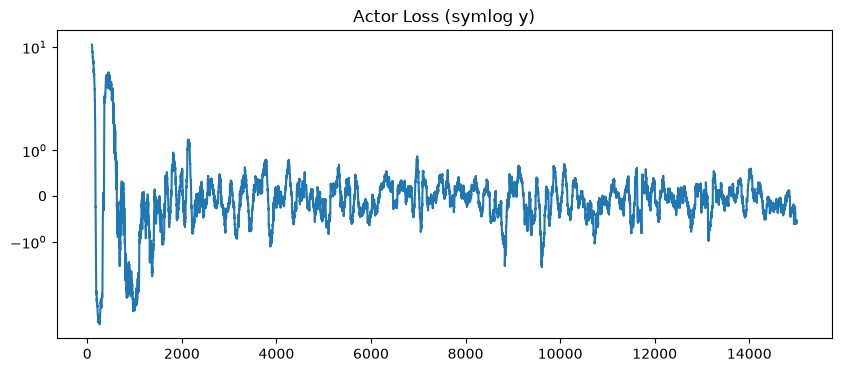

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df["step"], df["actor_loss"].rolling(window).mean())
plt.yscale("symlog")  # actor_loss = -logprob * advantage, 可正可负, 用 symlog
plt.title("Actor Loss (symlog y)")
plt.show()

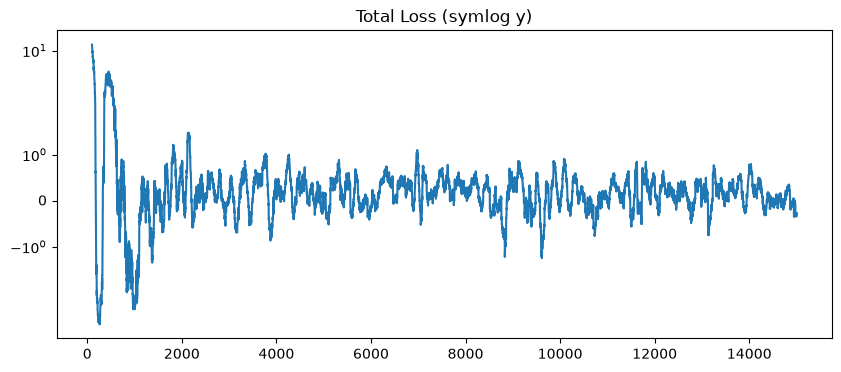

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df["step"], df["loss"].rolling(window).mean())
plt.yscale("symlog")  # 总 loss = actor_loss.sum() + clc*critic_loss.sum(), 可为负
plt.title("Total Loss (symlog y)")
plt.show()

In [11]:
# 用 render_mode="human" 打开可视化窗口，跑几局看训练好的策略表现
render_env = gym.make("CartPole-v1", render_mode="human")

N_EPISODES = 5
for ep in range(N_EPISODES):
    state, _ = render_env.reset()
    done = False
    truncated = False
    total = 0
    while not (done or truncated):
        with torch.no_grad():
            probs, _ = model(torch.from_numpy(state).float())
        action = int(torch.argmax(probs).item())  # greedy: 用 np.random.choice 采样也行
        state, reward, done, truncated, _ = render_env.step(action)
        total += reward
    print(f"episode {ep+1}: return = {total}")

render_env.close()


episode 1: return = 500.0
episode 2: return = 309.0
episode 3: return = 500.0
episode 4: return = 294.0
episode 5: return = 267.0
